# Notebook 0: Environment Setup & Audio Fundamentals

**What:** Verify the Demucs environment and understand core audio concepts (waveform, spectrogram, mix = sum of sources).

**Why:** Source separation models operate on audio representations. Understanding STFT and the supervised setup is essential.

**How:** Run checks, load a simple audio, visualize time vs frequency domain.

## 1. Environment Check

Verify PyTorch, CUDA, and Demucs are installed. For 3070 Ti: expect CUDA 11.x/12.x and ~8GB VRAM.

In [1]:
import torch
import torchaudio
import sys

print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Add demucs to path if running from repo
sys.path.insert(0, r'D:\demucs')
try:
    import demucs
    print(f"Demucs: OK")
except ImportError:
    print("Demucs: Run 'pip install demucs' or 'pip install -e .' from repo root")

Python: 3.10.19 | packaged by conda-forge | (main, Jan 26 2026, 23:39:36) [MSC v.1944 64 bit (AMD64)]
PyTorch: 2.5.1
CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU
VRAM: 8.59 GB
Demucs: OK


## 2. Waveform vs Spectrogram — First Principles

- **Waveform:** Raw audio samples `x[t]`. Shape: `(channels, samples)`.
- **Spectrogram:** Short-Time Fourier Transform (STFT). Represents frequency content over time. Shape: `(freq_bins, time_frames)`.

**Key relation:** `mix = drums + bass + vocals + other` (supervised learning setup)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Create synthetic "mix" from two sources (conceptual)
sr = 44100
duration = 1.0  # seconds
t = np.linspace(0, duration, int(sr * duration), dtype=np.float32)

source1 = 0.5 * np.sin(2 * np.pi * 440 * t)   # A4
source2 = 0.3 * np.sin(2 * np.pi * 880 * t)  # A5
mix = source1 + source2  # Linear mix

print("Waveform shapes:", source1.shape, mix.shape)
print("Mix = source1 + source2 (by definition in MSS)")

import IPython.display as ipd
ipd.Audio(mix, rate=sr)

Waveform shapes: (44100,) (44100,)
Mix = source1 + source2 (by definition in MSS)


In [4]:
# STFT using PyTorch (same idea as demucs.spec.spectro)

# Prepare waveform for STFT: mix is 1D (samples) -> need (channels, T) for torch.stft
# unsqueeze(0) adds channel dim -> (1, T); unsqueeze(0) adds batch dim -> (1, 1, T)
x = torch.from_numpy(mix).unsqueeze(0).unsqueeze(0)  # (1, 1, T)

# STFT parameters
n_fft = 1024      # FFT window size (samples). Larger -> finer frequency resolution, coarser time resolution.
hop = 256         # Hop length (samples between windows). hop < n_fft -> overlapping windows (overlap = n_fft - hop).

# Short-Time Fourier Transform: splits signal into overlapping windows, applies FFT to each.
# Input: (channels, T). Output: (channels, freq_bins, time_frames) complex tensor.
# freq_bins = n_fft//2 + 1 (due to real-valued input symmetry); time_frames ≈ (T - n_fft) // hop + 1.
spec = torch.stft(x.squeeze(0), n_fft, hop_length=hop, return_complex=True)

# Magnitude spectrogram: |z| discards phase. Common input for neural networks (phase often reconstructed separately).
mag = torch.abs(spec)

print("Spectrogram shape (freq_bins, time_frames):", mag.shape)

Spectrogram shape (freq_bins, time_frames): torch.Size([1, 513, 173])


d:\Miniconda3\envs\aeterna-mirror\lib\site-packages\torch\functional.py:704: UserWarning: A window was not provided. A rectangular window will be applied,which is known to cause spectral leakage. Other windows such as torch.hann_window or torch.hamming_window can are recommended to reduce spectral leakage.To suppress this warning and use a rectangular window, explicitly set `window=torch.ones(n_fft, device=<device>)`. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\SpectralOps.cpp:842.)
  return _VF.stft(  # type: ignore[attr-defined]


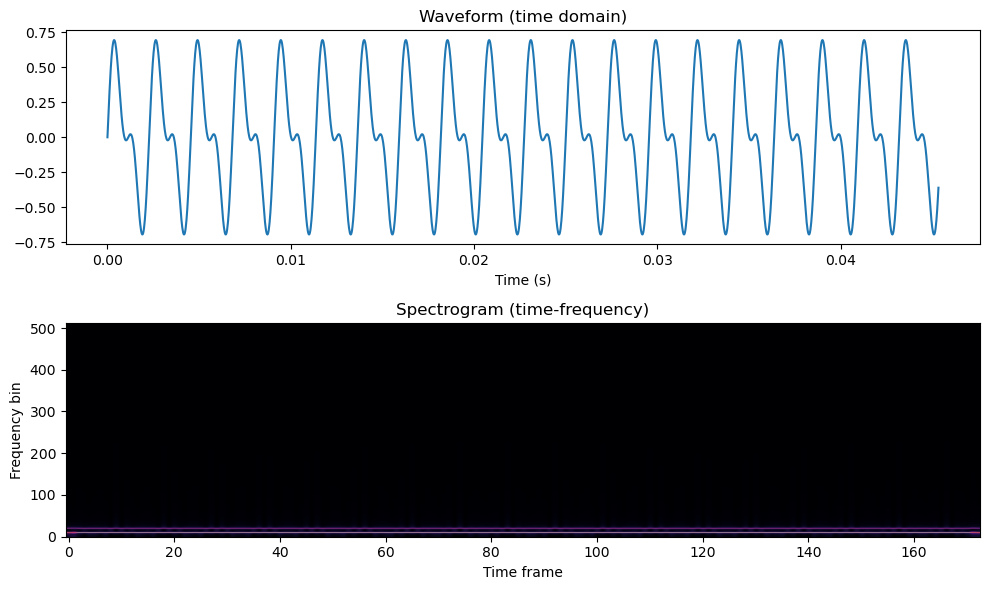

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
axes[0].plot(t[:2000], mix[:2000])
axes[0].set_title("Waveform (time domain)")
axes[0].set_xlabel("Time (s)")

axes[1].imshow(mag.squeeze().numpy(), aspect='auto', origin='lower', cmap='magma')
axes[1].set_title("Spectrogram (time-frequency)")
axes[1].set_xlabel("Time frame")
axes[1].set_ylabel("Frequency bin")
plt.tight_layout()
plt.show()

## 3. Demucs STFT Wrapper

Demucs uses `demucs.spec.spectro` and `ispectro` for hybrid models. Check that we can call them.

In [ ]:
from demucs.spec import spectro, ispectro

# ─── WHAT: Test signal ───────────────────────────────────────────────────────
# Random waveform of shape (batch=2, channels=1, samples=44100).
# 44100 samples @ 44.1 kHz ≈ 1 second of audio.
x = torch.randn(2, 1, 44100)  # (batch, channels, samples)

# ─── HOW: Forward transform (Waveform → Spectrogram) ──────────────────────────
# spectro() wraps torch.stft with Demucs defaults:
#   - Hann window (smooth taper, reduces spectral leakage)
#   - hop_length = n_fft//4 = 256 (75% overlap)
#   - normalized=True, center=True (consistent scaling, zero-pad edges)
# WHAT: z is complex-valued (batch, channels, freq_bins, time_frames)
z = spectro(x, n_fft=1024)

# ─── HOW: Inverse transform (Spectrogram → Waveform) ───────────────────────────
# ispectro() wraps torch.istft. Overlap-add reconstruction.
# WHY length=x.shape[-1]: iSTFT can yield variable length; we must specify
# the target length to match the original (critical for loss/metrics).
x_recon = ispectro(z, hop_length=256, length=x.shape[-1])

# ─── First-principles check: STFT is (approximately) invertible ───────────────
# With proper windowing + overlap-add, x ≈ x_recon. Small error is expected
# due to numerical precision and edge effects.
print("Input shape:", x.shape)
print("Spectrogram shape:", z.shape)
print("Reconstructed shape:", x_recon.shape)
print("Reconstruction error (approx):", (x - x_recon).abs().mean().item())

Input shape: torch.Size([2, 1, 44100])
Spectrogram shape: torch.Size([2, 1, 513, 173])
Reconstructed shape: torch.Size([2, 1, 44100])
Reconstruction error (approx): 8.198968259875983e-08


## 4. Summary

- **Waveform:** Raw samples; Demucs time branch works here.
- **Spectrogram:** STFT; Demucs frequency branch + hybrid models use it.
- **Mix:** Linear sum of sources. Model learns to invert this.

**Next:** Notebook 1 — Audio I/O and preprocessing in Demucs.